In [26]:
import itertools
import json

# Agora você pode alterar os índices dos parâmetros livremente!
param_given = [0, 1, 2]
param_then  = [4, 5, 6]
valores = [0, 25, 50 , 75, 101]
cenarios = []
count = 0

total_params = len(param_given) + len(param_then)

for comb in itertools.product(valores, repeat=total_params):
    # Gera as cláusulas 'given' usando os índices corretos em comb
    given = [f"p{i} >= {comb[idx]}" for idx, i in enumerate(param_given)]
    # Gera as cláusulas 'then' com os índices seguintes
    then  = [f"p{i} >= {comb[idx + len(param_given)]}" for idx, i in enumerate(param_then)]
    scenario = {
        "name": f"unanticipated_scenario_{count}",
        "given": " AND ".join(given),
        "when": "p3 >= 0",
        "do": "action_x",
        "then": " AND ".join(then)
    }
    cenarios.append(scenario)
    count += 1

print(f"Total de cenários gerados: {len(cenarios)}")

# Salvar em arquivo JSON
with open("shared_scenarios.json", "w", encoding="utf-8") as f:
    json.dump(cenarios, f, indent=2, ensure_ascii=False)


Total de cenários gerados: 15625


In [27]:
# só para pegar os results de similarity_result e candidate

import json

# Arquivo de entrada e saída
input_path = 'similarity_results.jsonl'
output_path = 'similarity_candidate.jsonl'

with open(input_path, 'r', encoding='utf-8') as fin, \
     open(output_path, 'w', encoding='utf-8') as fout:
    for line in fin:
        data = json.loads(line)
        # Monta novo dict apenas com os campos desejados
        new_data = {
            'similarity_result': data.get('similarity_result'),
            'candidate': data.get('candidate')
        }
        fout.write(json.dumps(new_data, ensure_ascii=False) + '\n')


In [28]:
import json
import pandas as pd
import re

def extract_param_values(clause_str, params):
    # Extrai o valor de cada parâmetro na string do tipo: 'p0 >= 0 AND p1 >= 0 ...'
    values = {}
    for p in params:
        match = re.search(fr"{p} >= (\d+)", clause_str)
        values[p] = int(match.group(1)) if match else None
    return values

param_given = ['p0', 'p1', 'p2']
param_then  = ['p4', 'p5', 'p6']
param_list = param_given + param_then

data = []
with open("similarity_candidate.jsonl", encoding="utf-8") as f:
    for line in f:
        d = json.loads(line)
        candidate = d["candidate"]
        given_vals = extract_param_values(candidate["given"], param_given)
        then_vals = extract_param_values(candidate["then"], param_then)
        row = {**given_vals, **then_vals, "similarity": d["similarity_result"]}
        data.append(row)

df = pd.DataFrame(data)
df


,p0,p1,p2,p4,p5,p6,similarity
0,0,0,0,0,0,0,0.666667
1,0,0,0,0,0,25,0.685186
2,0,0,0,0,0,50,0.722222
3,0,0,0,0,0,75,0.666667
4,0,0,0,0,0,101,0.611111
...,...,...,...,...,...,...,...
15620,101,101,101,101,101,0,0.388889
15621,101,101,101,101,101,25,0.407408
15622,101,101,101,101,101,50,0.444444
15623,101,101,101,101,101,75,0.388889


In [29]:
df

,p0,p1,p2,p4,p5,p6,similarity
0,0,0,0,0,0,0,0.666667
1,0,0,0,0,0,25,0.685186
2,0,0,0,0,0,50,0.722222
3,0,0,0,0,0,75,0.666667
4,0,0,0,0,0,101,0.611111
...,...,...,...,...,...,...,...
15620,101,101,101,101,101,0,0.388889
15621,101,101,101,101,101,25,0.407408
15622,101,101,101,101,101,50,0.444444
15623,101,101,101,101,101,75,0.388889


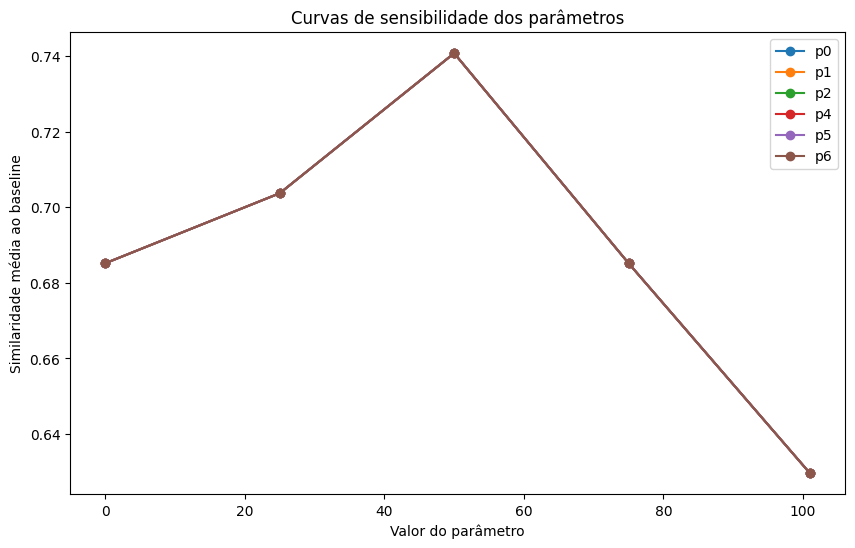

In [30]:
import matplotlib.pyplot as plt

param_cols = [col for col in df.columns if col.startswith('p')]
plt.figure(figsize=(10, 6))
for p in param_cols:
    means = df.groupby(p)['similarity'].mean()
    plt.plot(means.index, means.values, marker='o', label=p)

plt.xlabel("Valor do parâmetro")
plt.ylabel("Similaridade média ao baseline")
plt.title("Curvas de sensibilidade dos parâmetros")
plt.legend()
plt.show()


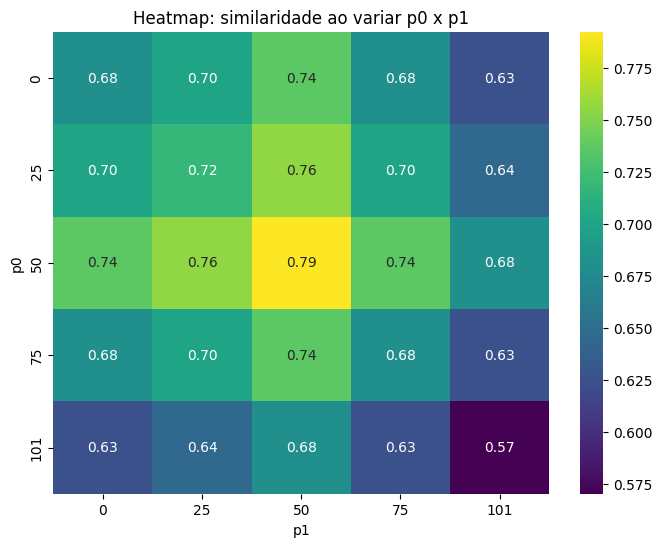

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Escolha dois parâmetros para analisar (troque p0 e p1 se quiser)
p1, p2 = "p0", "p1"
pivot = df.pivot_table(index=p1, columns=p2, values="similarity", aggfunc="mean")
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title(f"Heatmap: similaridade ao variar {p1} x {p2}")
plt.xlabel(p2)
plt.ylabel(p1)
plt.show()


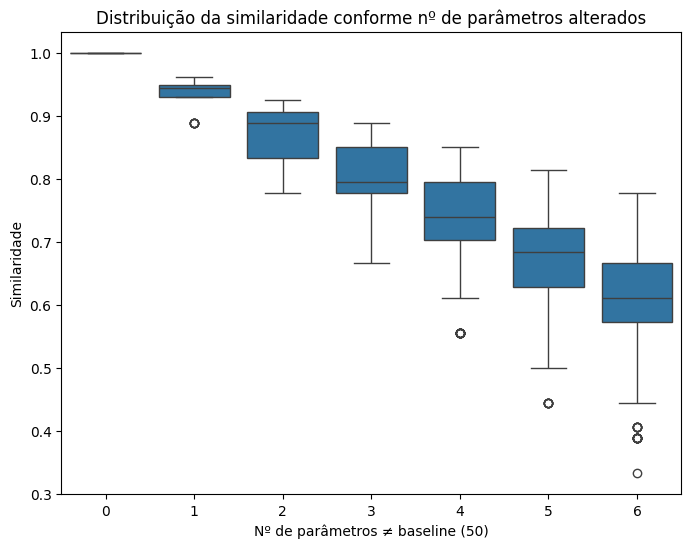

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

baseline_value = 50

df['num_perturbados'] = df[param_cols].apply(lambda row: sum(v != baseline_value for v in row), axis=1)

plt.figure(figsize=(8, 6))
sns.boxplot(x="num_perturbados", y="similarity", data=df)
plt.xlabel("Nº de parâmetros ≠ baseline (50)")
plt.ylabel("Similaridade")
plt.title("Distribuição da similaridade conforme nº de parâmetros alterados")
plt.show()


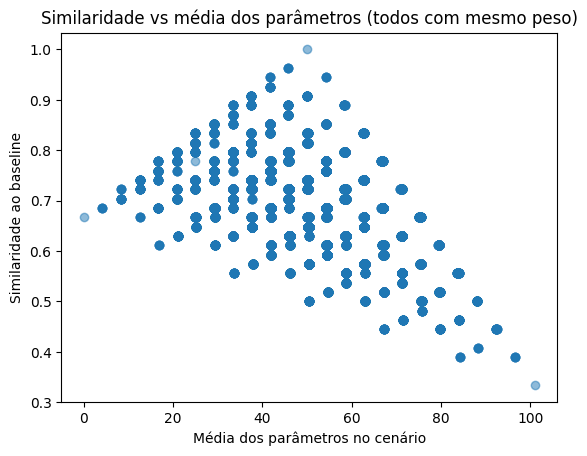

In [33]:
df["mean_param"] = df[param_cols].mean(axis=1)

import matplotlib.pyplot as plt
plt.scatter(df["mean_param"], df["similarity"], alpha=0.5)
plt.xlabel("Média dos parâmetros no cenário")
plt.ylabel("Similaridade ao baseline")
plt.title("Similaridade vs média dos parâmetros (todos com mesmo peso)")
plt.show()



In [34]:
import re
from typing import Dict, List

import numpy as np

def diversificar_candidatos_por_volume(
    diagnosed: Dict[str, str],
    alfas: List[float]
) -> List[Dict[str, str]]:
    """
    Gera candidatos a partir de um diagnosed, reduzindo ou expandindo a
    região permitida em uma fração alfa do volume original, para >=, >, <=, <.
    """

    def limitar_range(x):
        return min(max(x, 0.0), 1.0)

    def perturba_expr(expr, alpha):
        def substitui(m):
            var, op, val = m.group(1), m.group(2), float(m.group(3))
            # Região proporcional ao volume do intervalo
            if op in ('>=', '>'):
                # Região original: [val, 1], novo tamanho: (1-val)*alfa
                novo_val = 1 - (1 - val) * alpha
            elif op in ('<=', '<'):
                # Região original: [0, val], novo tamanho: val*alfa
                novo_val = val * alpha
            else:
                novo_val = val
            novo_val = limitar_range(novo_val)
            return f"{var} {op} {round(novo_val, 3)}"
        return re.sub(
            r"(p\d+)\s*(>=|<=|<|>)\s*([0-9.]+)",
            substitui,
            expr
        )

    candidates = []
    for alpha in alfas:
        candidate = {
            "alfa": alpha,
            "given": perturba_expr(diagnosed["given"], alpha),
            "when": diagnosed["when"],
            "do": diagnosed["do"],
            "then": perturba_expr(diagnosed["then"], alpha)
        }
        candidates.append(candidate)
    return candidates

# Exemplo de uso:
diagnosed = {
    "given": "p1 > 0.5 AND p2 >= 0.5 AND p3 >= 0.5",
    "when": "p4 >= 0",
    "do": "act",
    "then": "p5 >= 0.5 AND p6 >= 0.5 AND p7 >= 0.5"
}

# alfas = [0.00, 0.01, 0.05, 0.1, 0.25, 0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

alfas = np.arange(0.0, 2.01, 0.01)  # Vai de 0.0 até 2.0, inclusive
alfas = np.round(alfas, 4).tolist()  

# alfas = [0.7, 1.0, 1.3]  # 70%, 100%, 130% do volume original
candidates = diversificar_candidatos_por_volume(diagnosed, alfas)

for c in candidates:
    print(f"---\n# ALFA: {c['alfa']}\ngiven: {c['given']}\nwhen: {c['when']}\ndo: {c['do']}\nthen: {c['then']}\n")


---
# ALFA: 0.0
given: p1 > 1.0 AND p2 >= 1.0 AND p3 >= 1.0
when: p4 >= 0
do: act
then: p5 >= 1.0 AND p6 >= 1.0 AND p7 >= 1.0

---
# ALFA: 0.01
given: p1 > 0.995 AND p2 >= 0.995 AND p3 >= 0.995
when: p4 >= 0
do: act
then: p5 >= 0.995 AND p6 >= 0.995 AND p7 >= 0.995

---
# ALFA: 0.02
given: p1 > 0.99 AND p2 >= 0.99 AND p3 >= 0.99
when: p4 >= 0
do: act
then: p5 >= 0.99 AND p6 >= 0.99 AND p7 >= 0.99

---
# ALFA: 0.03
given: p1 > 0.985 AND p2 >= 0.985 AND p3 >= 0.985
when: p4 >= 0
do: act
then: p5 >= 0.985 AND p6 >= 0.985 AND p7 >= 0.985

---
# ALFA: 0.04
given: p1 > 0.98 AND p2 >= 0.98 AND p3 >= 0.98
when: p4 >= 0
do: act
then: p5 >= 0.98 AND p6 >= 0.98 AND p7 >= 0.98

---
# ALFA: 0.05
given: p1 > 0.975 AND p2 >= 0.975 AND p3 >= 0.975
when: p4 >= 0
do: act
then: p5 >= 0.975 AND p6 >= 0.975 AND p7 >= 0.975

---
# ALFA: 0.06
given: p1 > 0.97 AND p2 >= 0.97 AND p3 >= 0.97
when: p4 >= 0
do: act
then: p5 >= 0.97 AND p6 >= 0.97 AND p7 >= 0.97

---
# ALFA: 0.07
given: p1 > 0.965 AND p2 >= 0.965 